Tangential Vector Field (TVF) generation

In [1]:
from src.backend import TorchBackend, Backend
from src.geometry import Rectangle, Bitmap, Lattice, VectorObject, Ellipse
from src.layer import Layer
from src.material import Material
from src.tvf import TVF

import torch
import matplotlib.pyplot as plt
from typing import Any

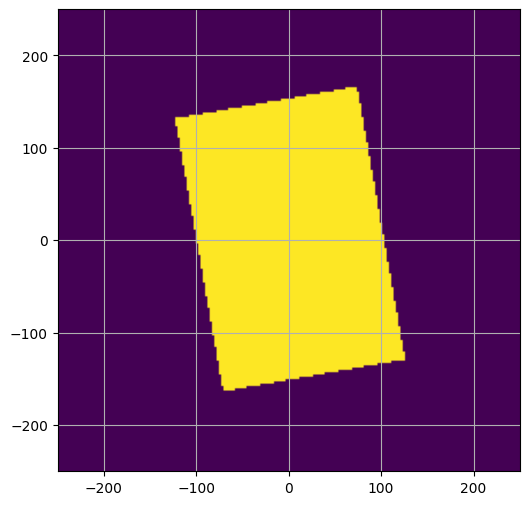

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (201, 201)
lattice = Lattice(period=period, grid=grid)

center = (0, 0)
size = (200, 300)
angle = 10.0*torch.pi/180

epsilon = [4.0, 2]
epsilon_bg = 1.0

mat = Material(backend, epsilon=epsilon)
mat_bg = Material(backend, epsilon=epsilon_bg)

shape = Rectangle(backend, lattice, center=center, size=size, material=mat, angle=angle, soft_mask=False)
layer = Layer(shape, thickness=500, material_bg=mat_bg)

epsilon_xy = layer.epsilon_xy()[:,0,0,:,:]

M = 20
N = 20

epsilon_mn = layer.epsilon_mn(2*M, 2*N)

plt.figure(figsize=(6,6))
plt.imshow(epsilon_xy[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.grid()

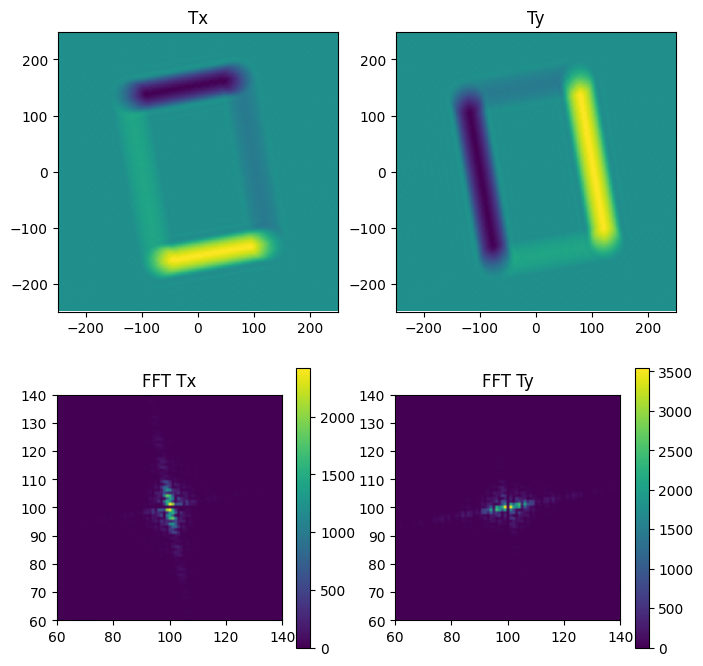

In [54]:
# Set field
field = epsilon_xy

# Generate TVF
tvf = TVF(backend, lattice, M, N, method='Pol', optimizer='LBFGS')

tx, ty = tvf.compute(field, alpha=1, beta=5e-6, gamma=0, steps=1)
tx_fft = backend.fftshift(backend.fft2(tx, dim=(-2, -1)), dim=(-2, -1))
ty_fft = backend.fftshift(backend.fft2(ty, dim=(-2, -1)), dim=(-2, -1))

batch = 0
plt.figure(figsize=(8,8))
plt.subplot(221)
plt.title('Tx')
plt.imshow(tx[batch,:,:].real.cpu().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))

plt.subplot(222)
plt.title('Ty')
plt.imshow(ty[batch,:,:].real.cpu().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.subplot(223)
plt.title('FFT Tx')
plt.imshow(tx_fft[batch,:,:].abs().cpu().T, origin='lower')
plt.colorbar()
plt.xlim(-2*M + tx_fft.shape[-2]//2, 2*M + tx_fft.shape[-2]//2)  
plt.ylim(-2*N + tx_fft.shape[-1]//2, 2*N + tx_fft.shape[-1]//2)

plt.subplot(224)
plt.title('FFT Ty')
plt.imshow(ty_fft[batch,:,:].abs().cpu().T, origin='lower')  
plt.xlim(-2*M + ty_fft.shape[-2]//2, 2*M + ty_fft.shape[-2]//2)  
plt.ylim(-2*N + ty_fft.shape[-1]//2, 2*N + ty_fft.shape[-1]//2)
plt.colorbar()
plt.show()

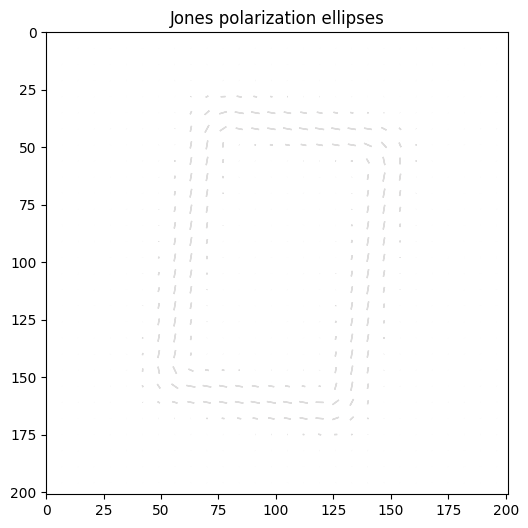

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_jones_ellipses(
    Jx, Jy,
    step=6,
    scale=0.8,
    ax=None,
    cmap="coolwarm"
):
    """
    Plot polarization ellipses from Jones field.
    
    Jx, Jy: complex arrays [Nx, Ny]
    step: subsampling
    scale: visual scale factor
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    Ex = Jx
    Ey = Jy

    # Stokes parameters
    S0 = np.abs(Ex)**2 + np.abs(Ey)**2
    S1 = np.abs(Ex)**2 - np.abs(Ey)**2
    S2 = 2*np.real(Ex*np.conj(Ey))
    S3 = -2*np.imag(Ex*np.conj(Ey))

    psi = 0.5 * np.arctan2(S2, S1)
    chi = 0.5 * np.arcsin(S3 / (S0 + 1e-12))

    a = scale * np.sqrt(S0) * np.cos(chi)
    b = scale * np.sqrt(S0) * np.sin(chi)

    Nx, Ny = Ex.shape
    for i in range(0, Nx, step):
        for j in range(0, Ny, step):
            if S0[i, j] < 1e-12:
                continue

            ellipse = Ellipse(
                (i, j),
                width=2*a[i, j],
                height=2*abs(b[i, j]),
                angle=np.degrees(psi[i, j]),
                fill=False,
                linewidth=1,
                color=plt.cm.coolwarm(0.5 + 0.5*np.sin(2*chi[i, j]))
            )
            ax.add_patch(ellipse)

    ax.set_aspect("equal")
    ax.set_xlim(0, Nx)
    ax.set_ylim(0, Ny)
    ax.set_title("Jones polarization ellipses")
    ax.invert_yaxis()
    return ax

plot_jones_ellipses(tx[batch].cpu().numpy(), ty[batch].cpu().numpy(), step=7, scale=2)
plt.show()

In [39]:
optimized_tvf.shape

AttributeError: 'tuple' object has no attribute 'shape'

In [6]:
optimized_tvf.shape

torch.Size([2, 201, 201, 2])

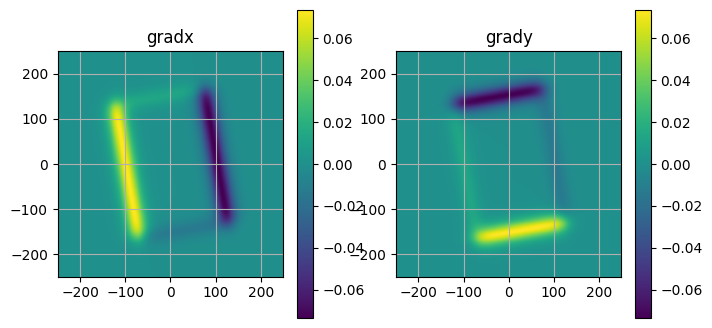

In [210]:
# Step 1: Compute gradients assuming periodic boundaries

def _grad_periodic(backend: Backend, lattice: Lattice, s: Any) -> tuple[Any, Any]:
    """
    Compute gradient of scalar field s.
    Use central differences with periodic boundary conditions.
    Normalize by lattice spacing to avoid incorrect gradient magnitude in anisotropic lattices.

    Parameters:
        backend: Backend
            Computational backend.
        lattice: Lattice
            Lattice object defining the grid and spacing.
        s: input scalar field
            shape: [B, Nx, Ny]
    Returns:
        sx, sy: [B, Nx, Ny]
    """
    # central differences with periodic boundary conditions
    gradx = 0.5 * (backend.roll(s, shifts=-1, dims=-2) - backend.roll(s, shifts=1, dims=-2))
    grady = 0.5 * (backend.roll(s, shifts=-1, dims=-1) - backend.roll(s, shifts=1, dims=-1))
    
    # Normalize by lattice spacing
    delta_x, delta_y = lattice.delta
    
    gradx = gradx / delta_x
    grady = grady / delta_y
    return gradx, grady

gradx, grady = _grad_periodic(backend, lattice, epsilon_xy)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gradx[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('gradx')
plt.colorbar()
plt.grid()
plt.subplot(1,2,2)
plt.imshow(grady[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('grady')
plt.colorbar()
plt.grid()
plt.show()

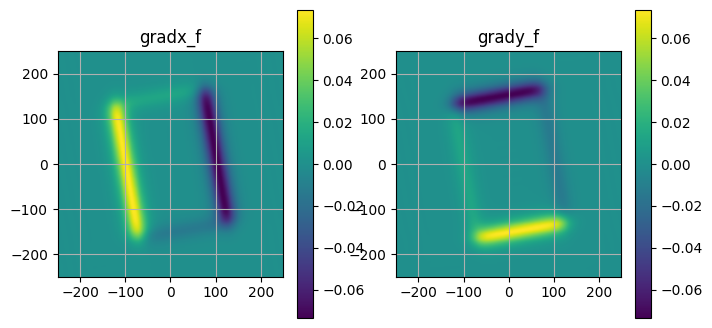

In [211]:
# Step 2: Filter and resample gradients
def low_pass_mask(backend: Backend, Nx: int, Ny: int, M: int, N: int) -> Any:
    """
    Create a low-pass filter mask in Fourier domain.

    Parameters:
        backend: Backend
            Computational backend.
        Nx: int
            Number of grid points in x direction.
        Ny: int
            Number of grid points in y direction.
        M: int
            Truncation order in x direction.
        N: int
            Truncation order in y direction.
    Returns:
        mask: [Nx, Ny], with ones in low-pass region and zeros elsewhere.
    """
    kx = backend.arange(0, Nx) - Nx//2
    ky = backend.arange(0, Ny) - Ny//2
    kx, ky = backend.meshgrid(kx, ky, indexing="ij")

    mask = (backend.abs(kx) <= M) & (backend.abs(ky) <= N)
    return mask

def low_pass_filter(backend: Backend, grad: tuple[Any, Any], M: int, N: int) -> Any:
    """
    Low-pass filter 2D data in Fourier domain.

    Parameters:
        backend: Backend
            Computational backend.
        grad: tuple[Any, Any]
            Gradients to be filtered. Each of shape [B, Nx, Ny].
        M: int
            Truncation order in x direction.
        N: int
            Truncation order in y direction.
    Returns:
        filtered_data: [B, Nx, Ny], but only low-pass components are non-zero.
    """
    # Sanity check
    if grad is None or len(grad) != 2:
        raise ValueError("Gradient must be a tuple of two components.")
    if grad[0].shape != grad[1].shape:
        raise ValueError("Gradient components must have the same shape.")
    
    gradx, grady = grad[0], grad[1]
    
    _, Nx, Ny = gradx.shape
    gradx_fft = backend.fft2(gradx, dim=(-2, -1))  # [B, Nx, Ny]
    grady_fft = backend.fft2(grady, dim=(-2, -1))  # [B, Nx, Ny]
    
    # Shift zero frequency component to center
    gradx_fft_shifted = backend.fftshift(gradx_fft, dim=(-2, -1))
    grady_fft_shifted = backend.fftshift(grady_fft, dim=(-2, -1))
    
    mask = low_pass_mask(backend, Nx, Ny, M, N)  # [Nx, Ny]
    mask = backend.astype(mask, gradx.dtype)
    
    filteredx_fft_shifted = gradx_fft_shifted * mask  # [B, Nx, Ny]
    filteredy_fft_shifted = grady_fft_shifted * mask  # [B, Nx, Ny]
    
    # Shift back
    filteredx_fft = backend.ifftshift(filteredx_fft_shifted, dim=(-2, -1))
    filteredy_fft = backend.ifftshift(filteredy_fft_shifted, dim=(-2, -1))
    
    # Inverse FFT to get filtered data
    filteredx = backend.ifft2(filteredx_fft)  # [B, Nx, Ny]
    filteredy = backend.ifft2(filteredy_fft)  # [B, Nx, Ny]
    
    return (filteredx, filteredy)

gradx_f, grady_f = low_pass_filter(backend, (gradx, grady), M=2*11, N=2*11)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gradx_f[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('gradx_f')
plt.colorbar()
plt.grid()
plt.subplot(1,2,2)
plt.imshow(grady_f[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('grady_f')
plt.colorbar()
plt.grid()
plt.show()

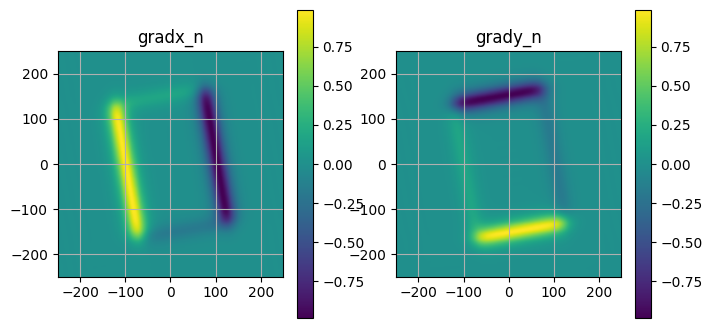

In [212]:
# Step 3: Global normalization
def _field_magnitude(backend: Backend, field: Any) -> Any:
    """
    Compute the magnitude of a 2D vector field.
    Safely handles sqrt for autograd.

    Parameters:
        backend: Backend
            Computational backend.
        field: Any
            Vector field. Shape: [B, Nx, Ny, 2].
    Returns:
        magnitude: Any
            Magnitude of the vector field. Shape: [B, Nx, Ny, 1].
    """
    # compute magnitude squared
    mag_sq = backend.sum(backend.abs(field) ** 2, dim=-1, keepdim=True)
    
    # avoid NaNs for grad at zero field
    is_zero = mag_sq == 0
    mag_sq_safe = backend.where(is_zero, backend.ones_like(mag_sq), mag_sq) # replace zeros with ones for safe sqrt
    mag = backend.where(is_zero, backend.zeros_like(mag_sq), backend.sqrt(mag_sq_safe)) # calculate magnitude
    
    return mag

def normalize_max_global(backend: Backend, field: Any) -> Any:
    """
    Normalize a 2D vector field by its global maximum magnitude.
    This is a global normalization (not elementwise), numerically safe.

    Parameters:
        backend: Backend
            Computational backend.
        vector_field: Any
            Vector field to be normalized. Shape: [B, Nx, Ny, 2].
    Returns:
        normalized_vector_field: Any
            Normalized vector field. Shape: [B, Nx, Ny, 2].
    """
    mag = _field_magnitude(backend, field)  # [B, Nx, Ny, 1]
    
    # global maximum magnitude
    max_mag = backend.amax(mag, dim=(-3, -2), keepdim=True)
    
    # avoid division by zero
    max_mag_safe = backend.where(max_mag == 0, 1, max_mag)

    return field / max_mag_safe

gradx_n, grady_n = normalize_max_global(backend, backend.stack((gradx_f, grady_f), dim=-1)).unbind(dim=-1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gradx_n[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('gradx_n')
plt.colorbar()
plt.grid()
plt.subplot(1,2,2)
plt.imshow(grady_n[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('grady_n')
plt.colorbar()
plt.grid()
plt.show()

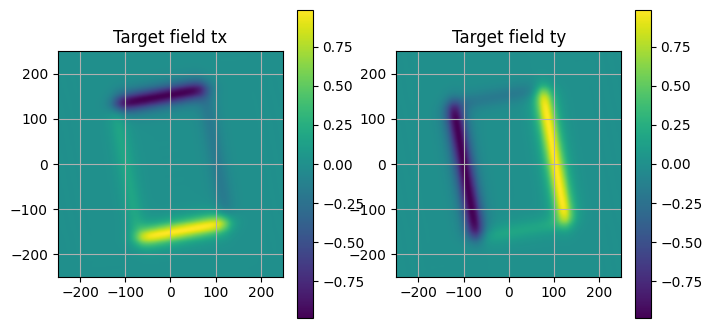

In [213]:
# Step 4: Define target field
target_field = backend.stack((grady_n, -gradx_n), dim=-1)  # tangential field shape: [B, Nx, Ny, 2] 

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(target_field[0,:,:,0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Target field tx')
plt.colorbar()
plt.grid()
plt.subplot(1,2,2)
plt.imshow(target_field[0,:,:,1].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Target field ty')
plt.colorbar()
plt.grid()
plt.show()

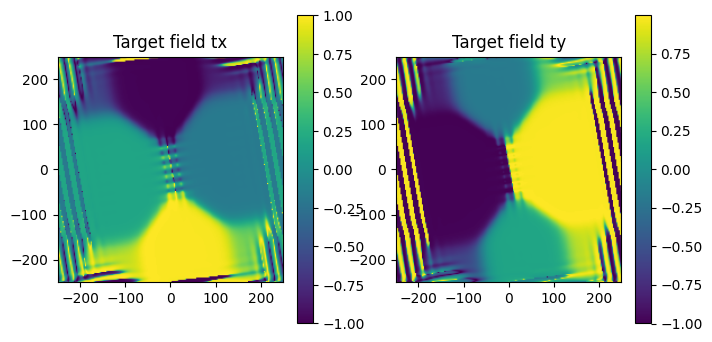

In [214]:
# Step 5: Normalize elementwise
def normalize_elementwise(backend: Backend, field: Any) -> Any:
    """
    Normalize a 2D vector field so that each element's magnitude is 1.
    This is an elementwise normalization, numerically safe.

    Parameters:
        backend: Backend
            Computational backend.
        vector_field: Any
            Vector field to be normalized. Shape: [B, Nx, Ny, 2].
    Returns:
        normalized_vector_field: Any
            Normalized vector field. Shape: [B, Nx, Ny, 2].
    """
    # compute magnitude squared
    mag_sq = backend.sum(backend.abs(field) ** 2, dim=-1, keepdim=True)
    
    # avoid NaNs for zero field
    is_zero = mag_sq == 0
    mag_sq_safe = backend.where(is_zero, backend.ones_like(mag_sq), mag_sq) # replace zeros with ones for safe sqrt
    mag = backend.sqrt(mag_sq_safe) # calculate magnitude

    return field / mag

target_field_n = normalize_elementwise(backend, target_field)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(target_field_n[0,:,:,0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Target field tx')
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(target_field_n[0,:,:,1].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Target field ty')
plt.colorbar()
plt.show()

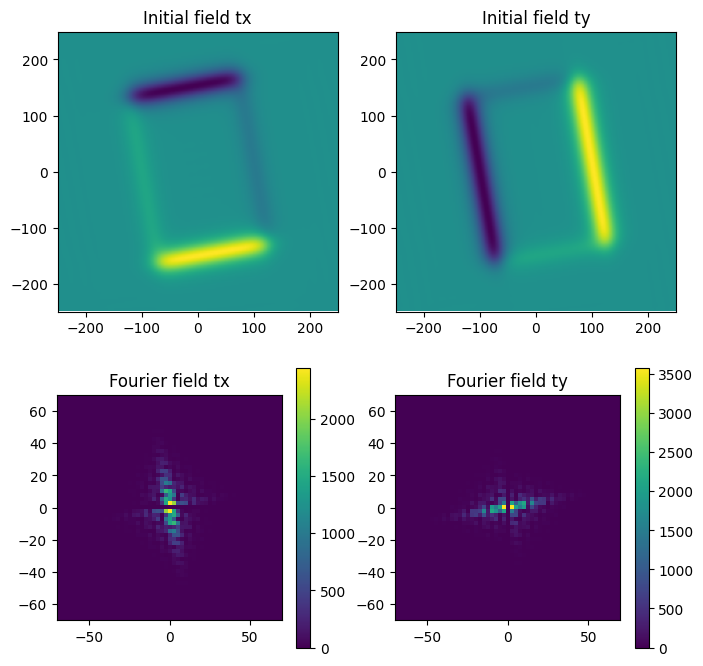

In [215]:
# Step 6: Define initial field

initial_field = target_field.clone()
fourier_field = backend.fftshift(backend.fft2(initial_field, dim=(-3, -2)), dim=(-3, -2))

xlim = 70
ylim = 70

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.imshow(initial_field[0,:,:,0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Initial field tx')

plt.subplot(2,2,2)
plt.imshow(initial_field[0,:,:,1].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Initial field ty')

plt.subplot(2,2,3)
plt.imshow(fourier_field[0,:,:,0].cpu().abs().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Fourier field tx')
plt.xlim([-xlim, xlim])
plt.ylim([-ylim, ylim])
plt.colorbar()

plt.subplot(2,2,4)
plt.imshow(fourier_field[0,:,:,1].cpu().abs().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Fourier field ty')
plt.xlim([-xlim, xlim])
plt.ylim([-ylim, ylim])
plt.colorbar()

plt.show()

In [95]:
# Step 7: Define alignment loss

def alignment_loss(backend: Backend, field: Any, target_field: Any, weights: Any) -> Any:
    """
    Compute alignment loss between field and target_field, weighted by weights.
    Loss = mean(weights * |field - target_field|^2)
    
    Parameters:
        backend: Backend
            Computational backend.
        field: Any
            Current vector field. Shape: [B, Nx, Ny, 2].
        target_field: Any
            Target vector field. Shape: [B, Nx, Ny, 2].
        weights: Any
            Weights for each element. Shape: [B, Nx, Ny, 1] or [B, Nx, Ny].
    
    Returns:
        loss: Any
            Alignment loss. Shape: [B].
    """
    if field.shape != target_field.shape:
        raise ValueError("field and target_field must have the same shape.")
    if weights.shape != field.shape[:-1] and weights.shape != field.shape[:-1] + (1,):
        raise ValueError("weights must have shape [B, Nx, Ny] or [B, Nx, Ny, 1].")
    
    diff = field - target_field  # [B, Nx, Ny, 2]
    diff_sq = backend.sum(backend.abs(diff) ** 2, dim=-1, keepdim=True)  # [B, Nx, Ny, 1]
    weighted_diff_sq = weights * diff_sq  # [B, Nx, Ny, 1] or [B, Nx, Ny]
    
    if weights.shape != field.shape[:-1]:
        weighted_diff_sq = backend.squeeze(weighted_diff_sq, dim=-1)  # [B, Nx, Ny]
        
    loss = backend.mean(weighted_diff_sq, dim=(-1, -2)) # [B]
    return loss

weights = _field_magnitude(backend, target_field)  # [B, Nx, Ny, 1]
loss_al = alignment_loss(backend, initial_field, target_field_n, weights)
print("Alignment loss:", loss_al.cpu().numpy())

Alignment loss: [0.02809367]


In [33]:
# Step 8: Define fourier regularization loss

def fourier_regularization_loss(backend: Backend, field: Any, period: tuple[float, float]) -> Any:
    """
    Compute Fourier regularization loss for a 2D vector field.
    Loss = mean(|k|^2 * |F(field)|^2), where F is the 2D FFT.

    Parameters:
        backend: Backend
            Computational backend.
        field: Any
            Vector field. Shape: [B, Nx, Ny, 2].
        period: tuple[float, float]
            Physical period of the lattice in x and y directions.
    """
    F_field = backend.fftshift(backend.fft2(field, dim=(-3, -2)), dim=(-3, -2))  # [B, Nx, Ny, 2]
    Lx, Ly = period
    
    # Calculate |k|^2
    _, Nx, Ny, _ = field.shape
    kx = 2* backend.pi / Lx * (backend.arange(0, Nx) - Nx//2)
    ky = 2* backend.pi / Ly * (backend.arange(0, Ny) - Ny//2)
    Kx, Ky = backend.meshgrid(kx, ky, indexing="ij")
    K_norm2 = Lx*Ly*(backend.abs(Kx) ** 2 + backend.abs(Ky) ** 2)  # [Nx, Ny]
    
    loss = backend.mean(K_norm2 * backend.sum(backend.abs(F_field) ** 2, dim=-1), dim=(-2, -1))  # [B]
    return loss
    
loss_f = fourier_regularization_loss(backend, initial_field, period=layer.period)
print("Fourier regularization loss:", 1e-9 * loss_f.cpu().numpy())

Fourier regularization loss: [0.00757319]


In [13]:
# Step 9: Define smoothness loss

def smoothness_loss(backend: Backend, lattice: Lattice, field: Any) -> Any:
    """
    Compute smoothness loss for a 2D vector field.
    Loss = mean(|grad(field)|^2)

    Parameters:
        backend: Backend
            Computational backend.
        field: Any
            Vector field. Shape: [B, Nx, Ny, 2].
            
    Returns:
        loss: Any
            Smoothness loss. Shape: [B].
    """
    field_x = field[:,:,:,0]  # [B, Nx, Ny]
    field_y = field[:,:,:,1]  # [B, Nx, Ny]
    
    gradx_x, grady_x = _grad_periodic(backend, lattice, field_x)  # [B, Nx, Ny]
    gradx_y, grady_y = _grad_periodic(backend, lattice, field_y)  # [B, Nx, Ny]
    
    grad_sq = backend.abs(gradx_x) ** 2 + backend.abs(grady_x) ** 2 + backend.abs(gradx_y) ** 2 + backend.abs(grady_y) ** 2  # [B, Nx, Ny]
    
    loss = backend.mean(grad_sq, dim=(-1, -2))  # [B]
    return loss

loss_s = smoothness_loss(backend, lattice, initial_field)
print("Smoothness loss:", loss_s.cpu().numpy())

Smoothness loss: [0.00068675]


In [34]:
# Step 10: Combine losses

def total_loss(backend: Backend, 
               field: Any, 
               target_field: Any, 
               weights: Any, 
               lattice: Lattice,
               alpha: float = 1.0,
               beta: float = 1e-3,
               gamma: float = 1.0) -> Any:
    """
    Compute total loss as a weighted sum of alignment loss, fourier regularization loss, and smoothness loss.
    
    Parameters:
        backend: Backend
            Computational backend.
        field: Any
            Current vector field. Shape: [B, Nx, Ny, 2].
        target_field: Any
            Target vector field. Shape: [B, Nx, Ny, 2].
        weights: Any
            Weights for alignment loss. Shape: [B, Nx, Ny, 1] or [B, Nx, Ny].
        lattice: Lattice
            Lattice object defining the grid and spacing.
        alpha: float
            Weight for alignment loss.
        beta: float
            Weight for fourier regularization loss.
        gamma: float
            Weight for smoothness loss.
    
    Returns:
        loss: Any
            Total loss. Shape: [B].
    """
    loss_al = alignment_loss(backend, field, target_field, weights)
    loss_f = fourier_regularization_loss(backend, field, lattice.period)
    loss_s = smoothness_loss(backend, lattice, field)
    
    total = alpha * loss_al + beta * loss_f + gamma * loss_s
    return total

weights = _field_magnitude(backend, target_field)  # [B, Nx, Ny, 1]
loss = total_loss(backend, initial_field, target_field_n, weights, lattice, alpha=1.0, beta=1e-9, gamma=1.0)
print("Total loss:", loss.cpu().numpy())

Total loss: [0.03635362]


In [220]:
from torch.optim import LBFGS

field = fourier_field.clone().detach()
weights = _field_magnitude(backend, target_field)   
weights = weights.detach()

P = backend.stack([field.real, field.imag], dim=-1).clone().detach().requires_grad_(True)

print('Initial alignment loss:', alignment_loss(backend, initial_field.detach(), target_field_n, weights).cpu().numpy())
print('Initial fourier regularization loss:', fourier_regularization_loss(backend, initial_field.detach(), lattice.period).cpu().numpy())
print('Initial smoothness loss:', smoothness_loss(backend, lattice, initial_field.detach()).cpu().numpy())

optimizer = LBFGS(
    [P],
    max_iter=20,
    tolerance_grad=1e-8,
    tolerance_change=1e-8,
    line_search_fn="strong_wolfe",
)

def closure():
    optimizer.zero_grad()
    F = P[...,0] + 1j * P[...,1]
    field_pr = backend.ifft2(backend.ifftshift(F, dim=(-3, -2)), dim=(-3, -2))

    loss = total_loss(
        backend,
        field_pr,
        target_field_n,
        weights,
        lattice,
        alpha=1.0,
        beta=5e-8,
        gamma=30.0,
    )

    loss = backend.sum(loss)
    loss.backward()
    return loss

n_steps = 1
for i in range(n_steps):
    loss = optimizer.step(closure)
    print(f"Step {i+1}/{n_steps}, Loss: {loss.item():.6e}")

field = backend.ifft2(backend.ifftshift(P[...,0] + 1j * P[...,1], dim=(-3, -2)), dim=(-3, -2))
print("Optimization complete.")
print("alignment loss:", alignment_loss(backend, field.detach(), target_field_n, weights).cpu().numpy())
print("fourier regularization loss:", fourier_regularization_loss(backend, field.detach(), lattice.period).cpu().numpy())
print("smoothness loss:", smoothness_loss(backend, lattice, field.detach()).cpu().numpy())


Initial alignment loss: [0.03068583]
Initial fourier regularization loss: [2121681.33200996]
Initial smoothness loss: [0.00020734]
Step 1/1, Loss: 1.429901e-01
Optimization complete.
alignment loss: [0.03068583]
fourier regularization loss: [2121681.33200996]
smoothness loss: [0.00020734]


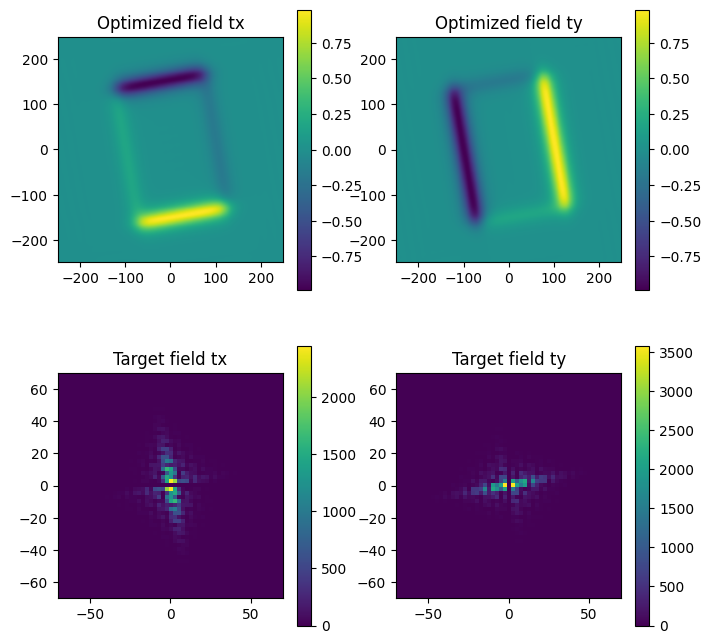

In [221]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.imshow(field[0,:,:,0].detach().cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Optimized field tx')
plt.colorbar()

plt.subplot(2,2,2)
plt.imshow(field[0,:,:,1].detach().cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Optimized field ty')
plt.colorbar()

plt.subplot(2,2,3)
plt.imshow(backend.fftshift(backend.fft2(field[0,:,:,0])).detach().cpu().abs().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/ 2, period[1]/2))
plt.title('Target field tx')
plt.colorbar()
plt.xlim(-70, 70)
plt.ylim(-70, 70)

plt.subplot(2,2,4)
plt.imshow(backend.fftshift(backend.fft2(field[0,:,:,1])).detach().cpu().abs().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.title('Target field ty')
plt.colorbar()
plt.xlim(-70, 70)
plt.ylim(-70, 70)
plt.show()

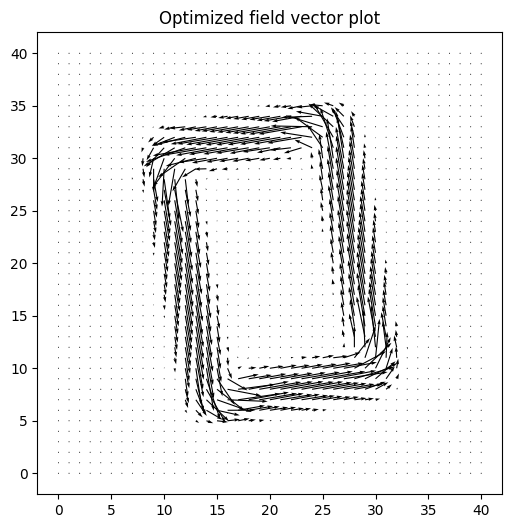

In [208]:
step = 5  # try 3, 5, 8, 10

u = field[0, ::step, ::step, 0].detach().cpu().real.T
v = field[0, ::step, ::step, 1].detach().cpu().real.T

plt.figure(figsize=(6,6))
plt.quiver(u, v, scale=3)
plt.title('Optimized field vector plot')
plt.show()